In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

# --- PATH SETUP ---
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

# --- LOCAL IMPORTS ---
%load_ext autoreload
%autoreload 2
from src.analysis import processing as proc
from src.analysis import plotting as viz

# Global Storage for Final Comparison
ALL_RESULTS = {} 

# --- PLOTTING STYLE ---
plt.style.use('seaborn-v0_8-paper')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 120

print(f"Project Root set to: {project_root}")
print("Modules loaded successfully.")

Project Root set to: /Users/ramsaydavis/dla
Modules loaded successfully.


In [ ]:
# General Config
SIZE_LABEL = '1M'
TEST_LIMIT = 100   
NUM_CORES  = 4     


%% LATTICE ANALYSIS %%

In [ ]:
MODEL_NAME1 = 'Lattice'


# Define Paths
base_path1 = os.path.join(project_root, f'results/analysis_clusters/{MODEL_NAME1}/{SIZE_LABEL}/*.npz')

print(f"Targeting Model: {MODEL_NAME1}")
print(f"Targeting Size:  {SIZE_LABEL}")
print(f"Test Limit:      {TEST_LIMIT} files")
print(f"Search Path:     {base_path1}")

Targeting Model: Lattice
Targeting Size:  1M
Test Limit:      100 files
Search Path:     /Users/ramsaydavis/dla/results/analysis_clusters/Lattice/1M/*.npz


Growth Rate + Dimension

In [ ]:
print(">>> Running Basic Scalar Analysis...")

snapshots = [1000000] 

df_basic = proc.batch_analysis(
    file_pattern=base_path1, 
    snapshots=snapshots, 
    num_workers=NUM_CORES, 
    limit=TEST_LIMIT
)

# Display Summary
print("\n--- RESULTS SUMMARY ---")
print(f"Files Processed: {len(df_basic)}")
if not df_basic.empty:
    mean_beta = df_basic['beta'].mean()
    std_beta  = df_basic['beta'].std()
    mean_D    = df_basic['D'].mean()
    std_D     = df_basic['D'].std()
    
    print(f"Growth Rate (Beta): {mean_beta:.4f} ± {std_beta:.4f}")
    print(f"Fractal Dim (D):    {mean_D:.4f} ± {std_D:.4f}")
else:
    print("Error: DataFrame is empty.")

df_basic.head()

>>> Running Basic Scalar Analysis...
Limiting to first 100 files for analysis.
Found 100 files to process. Starting analysis on 4 cores...


100%|██████████| 100/100 [01:16<00:00,  1.31it/s]



--- RESULTS SUMMARY ---
Files Processed: 100
Growth Rate (Beta): 0.5937 ± 0.0075
Fractal Dim (D):    1.6314 ± 0.0034


,filepath,snapshot_N,beta,beta_err,Rg_final,D,D_err
0,/Users/ramsaydavis/dla/results/analysis_cluste...,1000000,0.603485,0.000009,1615.382113,1.634700,0.008884
1,/Users/ramsaydavis/dla/results/analysis_cluste...,1000000,0.605948,0.000010,1679.677731,1.636029,0.008866
2,/Users/ramsaydavis/dla/results/analysis_cluste...,1000000,0.580472,0.000006,1608.069174,1.625964,0.008654
3,/Users/ramsaydavis/dla/results/analysis_cluste...,1000000,0.589035,0.000005,1589.566621,1.626574,0.008655
4,/Users/ramsaydavis/dla/results/analysis_cluste...,1000000,0.594471,0.000006,1612.640671,1.631458,0.008663


In [ ]:
# --- STEP 2: SECTOR EVOLUTION ANALYSIS ---
print(">>> Running Sector Evolution Analysis...")

# extract full history (Rg vs Time) for 360 sectors
times, sector_data = proc.batch_sector_analysis(
    file_pattern=base_path1, 
    num_sectors=360, 
    num_workers=NUM_CORES, 
    limit=TEST_LIMIT
)

# Quality Check
if sector_data is not None:
    print("\n--- DATA SHAPE CHECK ---")
    print(f"Time Points (Checkpoints): {len(times)}")
    print(f"Time Values: {times}")
    print(f"Data Array (Files, Sectors, Times): {sector_data.shape}")
    
    # Sanity check: Should not be all zeros
    print(f"Mean Rg at final time: {np.nanmean(sector_data[:, :, -1]):.2f}")
else:
    print("Error: Sector analysis failed.")

>>> Running Sector Evolution Analysis...
Limiting to first 100 files for sector analysis.
Found 100 files to process for sector analysis on 4 cores...


100%|██████████| 100/100 [00:30<00:00,  3.28it/s]

Aggregated shape: (100, 360, 10) (files, sectors, time_steps)

--- DATA SHAPE CHECK ---
Time Points (Checkpoints): 10
Time Values: [  1024   2048   4096   8192  16384  32768  65536 131072 262144 524288]
Data Array (Files, Sectors, Times): (100, 360, 10)
Mean Rg at final time: 871.80


In [5]:
# --- STEP 3: COMPUTE ANISOTROPY STATISTICS ---
if sector_data is not None:
    print(">>> Computing Anisotropy Statistics...")
    
    # Calculate metrics for every single file in the batch
    # df_stats: DataFrame containing individual Beta_Ratio and Fourier_Score for each file
    # summary:  Dictionary containing the Mean +/- Std of the population
    df_stats, summary = proc.compute_anisotropy_metrics(times, sector_data)
    
    print("\n--- ANISOTROPY RESULTS ---")
    print(f"Beta Ratio (Beta_Ax / Beta_Diag): {summary['beta_ratio_mean']:.4f} ± {summary['beta_ratio_std']:.4f}")
    print(f"Anisotropy Score  (Fourier A4 / A0):     {summary['fourier_score_mean']:.4f} ± {summary['fourier_score_std']:.4f}")
    
    # Optional: Peek at the raw data to ensure no NaNs are skewing things
    print(f"\nValid Files Used: {len(df_stats.dropna())} / {len(df_stats)}")
    display(df_stats.head())
else:
    print("Skipping metrics (No data).")

>>> Computing Anisotropy Statistics...
Computing anisotropy metrics for 100 files...

--- ANISOTROPY RESULTS ---
Beta Ratio (Beta_Ax / Beta_Diag): 1.1421 ± 0.1106
Anisotropy Score  (Fourier A4 / A0):     0.0489 ± 0.0208

Valid Files Used: 100 / 100


,beta_axis,beta_diag,beta_ratio,A0,A4,fourier_score
0,0.626823,0.424227,1.477564,0.571812,0.052736,0.092225
1,0.609253,0.470874,1.293876,0.582186,0.037295,0.064060
2,0.581421,0.512944,1.133498,0.576137,0.021960,0.038116
3,0.583947,0.573087,1.018950,0.562806,0.028141,0.050002
4,0.576428,0.550722,1.046675,0.568736,0.020899,0.036747


/Users/ramsaydavis/dla/src/analysis/plotting.py:76: RuntimeWarning: Mean of empty slice
  mean_profile = np.nanmean(agg_data, axis=0)  # shape: (num_sectors, time_points)
/Users/ramsaydavis/dla/src/analysis/plotting.py:144: RuntimeWarning: Mean of empty slice
  mean_grid = np.nanmean(agg_data, axis=0)


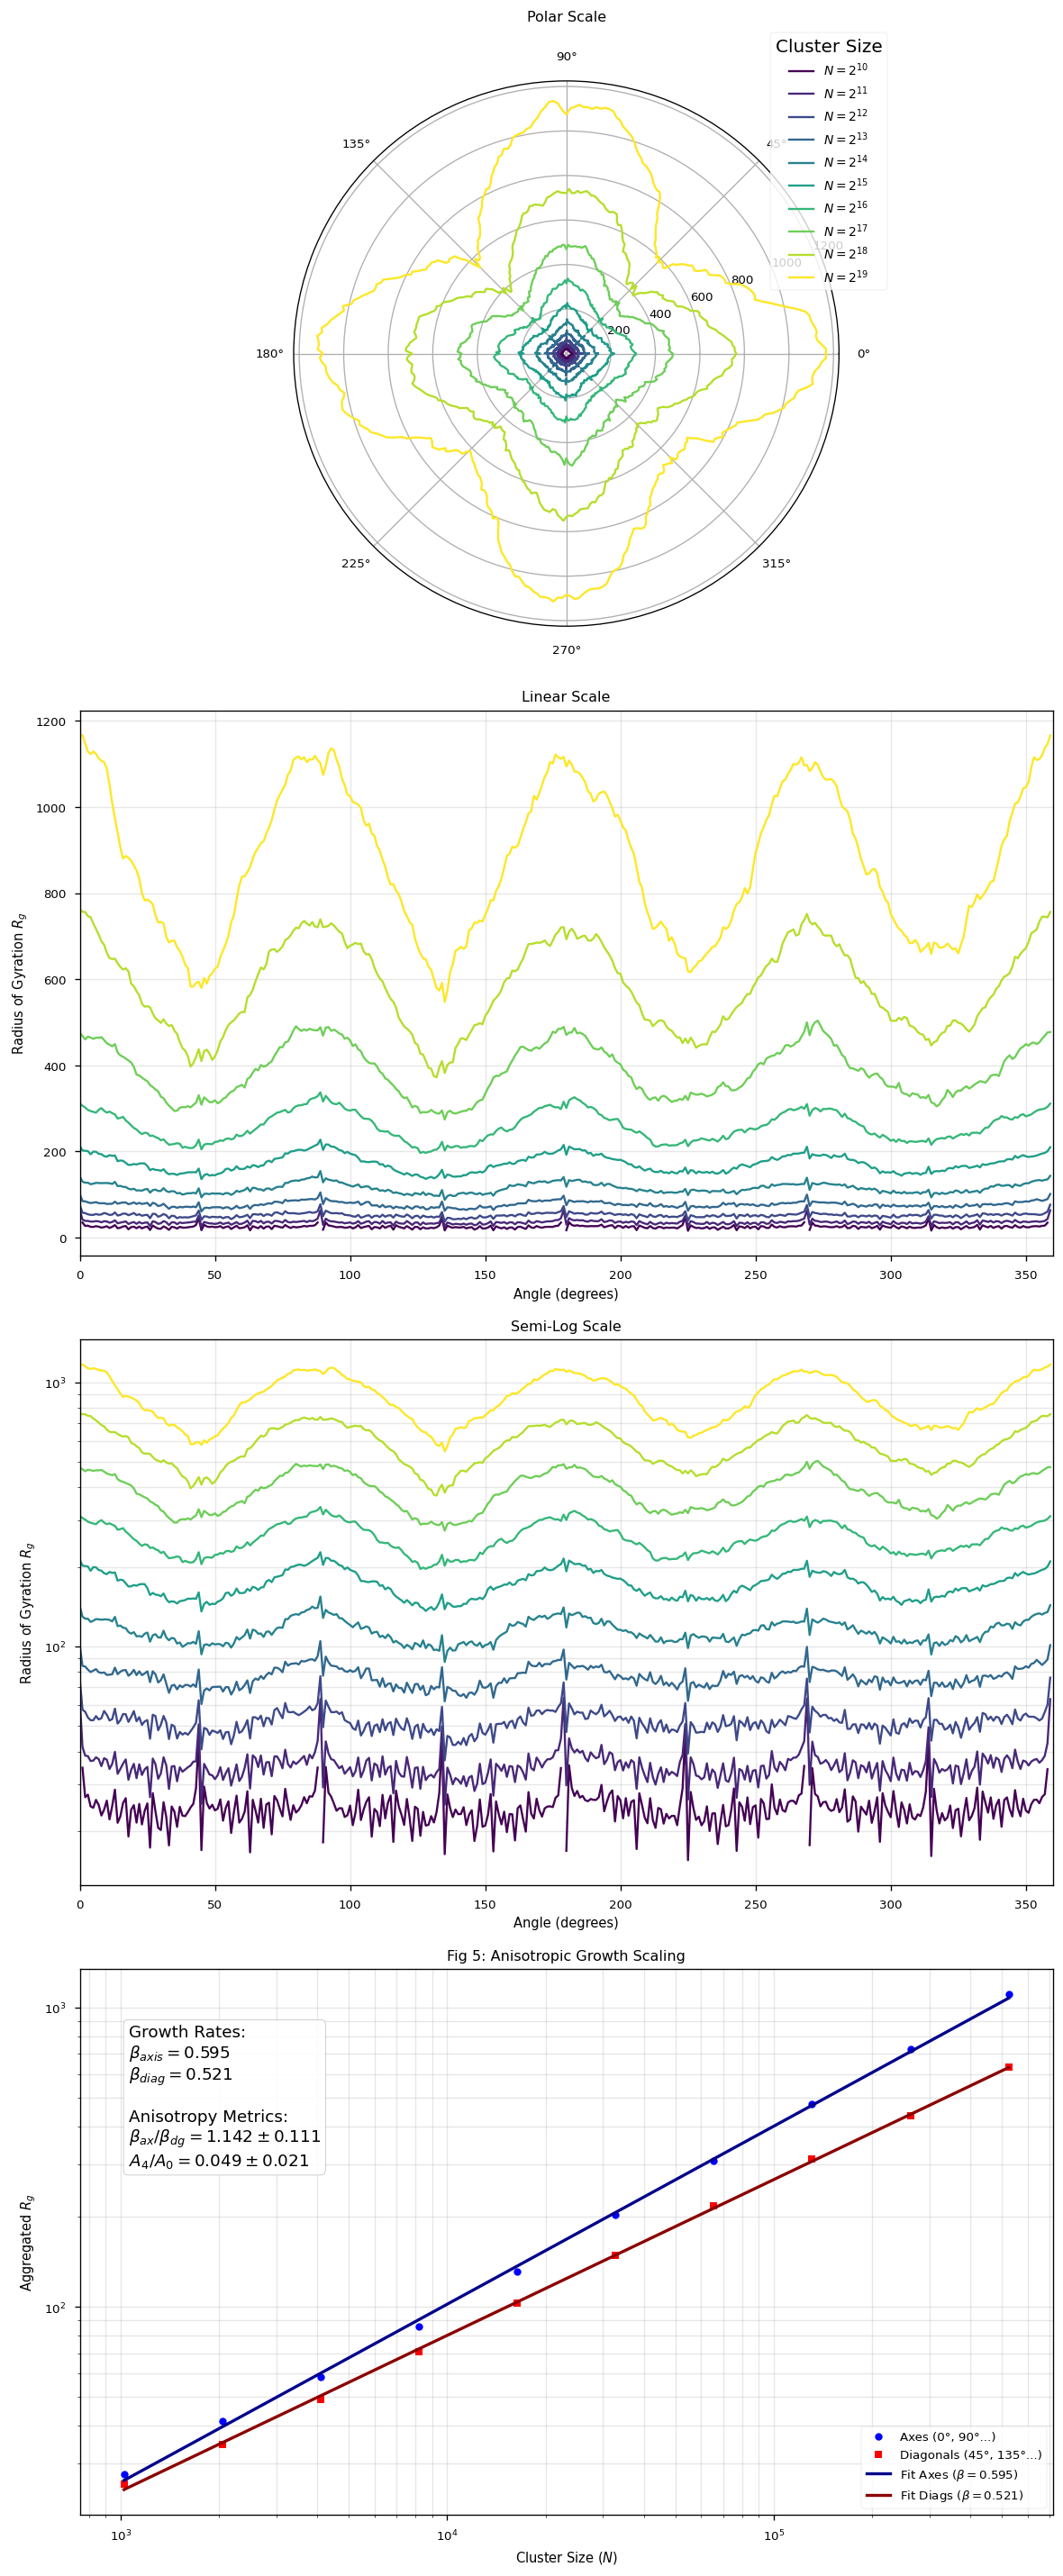

In [6]:
# --- STEP 4: VISUALISATION ---
if sector_data is not None:
    # 5 rows: Polar, Linear, Semi-Log, Beta, Scaling Laws
    fig = plt.figure(figsize=(10, 28))
    ax_polar = fig.add_subplot(5, 1, 1, projection='polar')
    ax_linear = fig.add_subplot(5, 1, 2)
    ax_log = fig.add_subplot(5, 1, 3)
    ax_beta = fig.add_subplot(5, 1, 4)
    ax_scale = fig.add_subplot(5, 1, 5)
    viz.angular_rg_plot(times, sector_data, ax_polar=ax_polar, ax_linear=ax_linear, ax_log=ax_log)
    viz.plot_beta_profile(times, sector_data, ax=ax_beta)
    viz.comparing_axes_plot(times, sector_data, summary_stats=summary, ax=ax_scale)
    
    # Adjust spacing to prevent labels overlapping
    plt.tight_layout()
    plt.show()
else:
    print("No data to plot.")

>>> Generating Density Map...
Generating density grid for N=1000000 across 100 files...
Processed 100 files...
Completed density grid generation for 100 files.


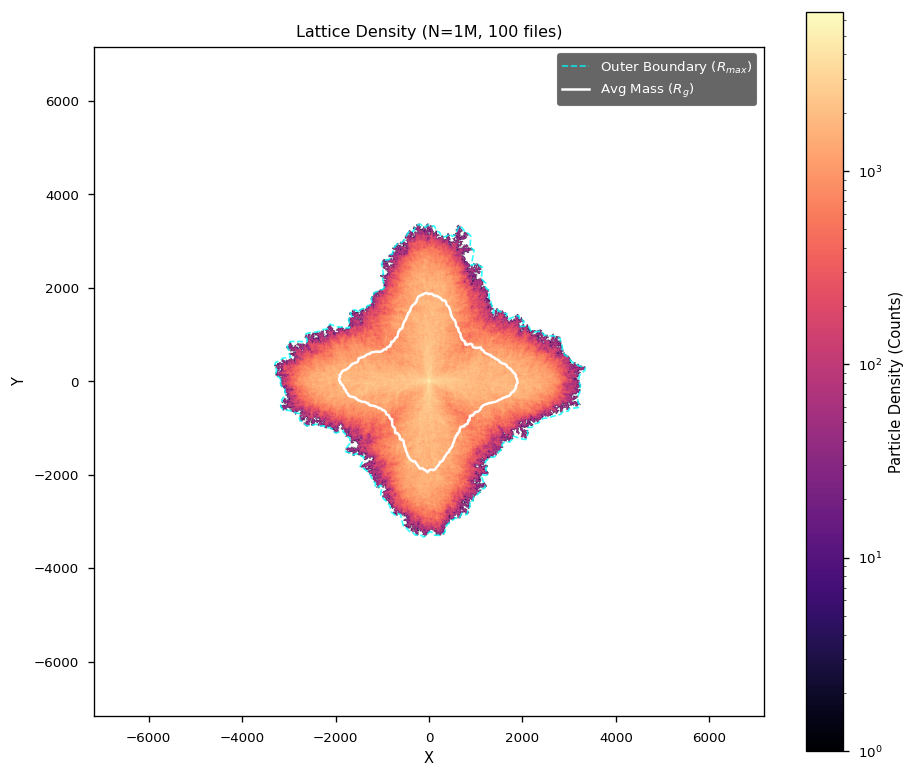

In [ ]:
# --- STEP 5: DENSITY MAP VERIFICATION ---
print(">>> Generating Density Map...")

grid, bins, max_r, rg_curve = proc.generate_density_grid(
    file_pattern=base_path1, 
    snapshot_N=1000000, 
    limit_files=TEST_LIMIT # Use same limit for consistency
)

fig = viz.plot_density_map(
    grid, bins, 
    max_r_curve=max_r, 
    rg_curve=rg_curve, 
    title=f"{MODEL_NAME1} Density (N=1M, {TEST_LIMIT} files)"
)
plt.show()

%% OFF_LATTICE %%

In [7]:
MODEL_NAME2 = 'OffLattice'


# Define Paths
base_path2 = os.path.join(project_root, f'results/analysis_clusters/{MODEL_NAME2}/{SIZE_LABEL}/*.npz')

print(f"Targeting Model: {MODEL_NAME2}")
print(f"Targeting Size:  {SIZE_LABEL}")
print(f"Test Limit:      {TEST_LIMIT} files")
print(f"Search Path:     {base_path2}")

Targeting Model: OffLattice
Targeting Size:  1M
Test Limit:      100 files
Search Path:     /Users/ramsaydavis/dla/results/analysis_clusters/OffLattice/1M/*.npz


In [8]:
print(">>> Running Basic Scalar Analysis...")

snapshots = [1000000] 

df_basic2 = proc.batch_analysis(
    file_pattern=base_path2, 
    snapshots=snapshots, 
    num_workers=NUM_CORES, 
    limit=TEST_LIMIT
)

# Display Summary
print("\n--- RESULTS SUMMARY ---")
print(f"Files Processed: {len(df_basic)}")
if not df_basic2.empty:
    mean_beta = df_basic2['beta'].mean()
    std_beta  = df_basic2['beta'].std()
    mean_D    = df_basic2['D'].mean()
    std_D     = df_basic2['D'].std()
    
    print(f"Growth Rate (Beta): {mean_beta:.4f} ± {std_beta:.4f}")
    print(f"Fractal Dim (D):    {mean_D:.4f} ± {std_D:.4f}")
else:
    print("Error: DataFrame is empty.")

df_basic2.head()

>>> Running Basic Scalar Analysis...
Limiting to first 100 files for analysis.
Found 100 files to process. Starting analysis on 4 cores...


100%|██████████| 100/100 [02:13<00:00,  1.34s/it]


--- RESULTS SUMMARY ---
Files Processed: 100
Growth Rate (Beta): 0.5831 ± 0.0069
Fractal Dim (D):    1.6246 ± 0.0029


,filepath,snapshot_N,beta,beta_err,Rg_final,D,D_err
0,/Users/ramsaydavis/dla/results/analysis_cluste...,1000000,0.579934,0.000003,1618.132440,1.624509,0.008414
1,/Users/ramsaydavis/dla/results/analysis_cluste...,1000000,0.581012,0.000007,1636.166260,1.627322,0.008109
2,/Users/ramsaydavis/dla/results/analysis_cluste...,1000000,0.586783,0.000005,1609.102964,1.630393,0.009162
3,/Users/ramsaydavis/dla/results/analysis_cluste...,1000000,0.583914,0.000007,1614.227545,1.627561,0.009090
4,/Users/ramsaydavis/dla/results/analysis_cluste...,1000000,0.569147,0.000005,1542.224023,1.622238,0.008664


In [9]:
# --- STEP 2: SECTOR EVOLUTION ANALYSIS ---
print(">>> Running Sector Evolution Analysis...")

# extract full history (Rg vs Time) for 360 sectors
times, sector_data2 = proc.batch_sector_analysis(
    file_pattern=base_path2, 
    num_sectors=360, 
    num_workers=NUM_CORES, 
    limit=TEST_LIMIT
)

# Quality Check
if sector_data2 is not None:
    print("\n--- DATA SHAPE CHECK ---")
    print(f"Time Points (Checkpoints): {len(times)}")
    print(f"Time Values: {times}")
    print(f"Data Array (Files, Sectors, Times): {sector_data2.shape}")
    
    # Sanity check: Should not be all zeros
    print(f"Mean Rg at final time: {np.nanmean(sector_data2[:, :, -1]):.2f}")
else:
    print("Error: Sector analysis failed.")

>>> Running Sector Evolution Analysis...
Limiting to first 100 files for sector analysis.
Found 100 files to process for sector analysis on 4 cores...


100%|██████████| 100/100 [00:43<00:00,  2.30it/s]

Aggregated shape: (100, 360, 10) (files, sectors, time_steps)

--- DATA SHAPE CHECK ---
Time Points (Checkpoints): 10
Time Values: [  1024   2048   4096   8192  16384  32768  65536 131072 262144 524288]
Data Array (Files, Sectors, Times): (100, 360, 10)
Mean Rg at final time: 916.96


In [10]:
# --- STEP 3: COMPUTE ANISOTROPY STATISTICS ---
if sector_data2 is not None:
    print(">>> Computing Anisotropy Statistics...")
    
    # Calculate metrics for every single file in the batch
    # df_stats: DataFrame containing individual Beta_Ratio and Fourier_Score for each file
    # summary:  Dictionary containing the Mean +/- Std of the population
    df_stats2, summary2 = proc.compute_anisotropy_metrics(times, sector_data2)
    
    print("\n--- ANISOTROPY RESULTS ---")
    print(f"Beta Ratio (Beta_Ax / Beta_Diag): {summary2['beta_ratio_mean']:.4f} ± {summary2['beta_ratio_std']:.4f}")
    print(f"Anisotropy Score  (Fourier A4 / A0):     {summary2['fourier_score_mean']:.4f} ± {summary2['fourier_score_std']:.4f}")
    
    # Optional: Peek at the raw data to ensure no NaNs are skewing things
    print(f"\nValid Files Used: {len(df_stats2.dropna())} / {len(df_stats2)}")
    display(df_stats2.head())
else:
    print("Skipping metrics (No data).")

>>> Computing Anisotropy Statistics...
Computing anisotropy metrics for 100 files...


Anisotropy Metrics: 100%|██████████| 100/100 [00:39<00:00,  2.54it/s]


--- ANISOTROPY RESULTS ---
Beta Ratio (Beta_Ax / Beta_Diag): 1.0071 ± 0.1093
Anisotropy Score  (Fourier A4 / A0):     0.0337 ± 0.0170

Valid Files Used: 100 / 100


,beta_axis,beta_diag,beta_ratio,A0,A4,fourier_score
0,0.558335,0.594030,0.939910,0.571045,0.008977,0.015721
1,0.561629,0.573344,0.979567,0.581650,0.020169,0.034676
2,0.621334,0.563931,1.101791,0.563048,0.027085,0.048104
3,0.577266,0.572976,1.007488,0.576380,0.018459,0.032026
4,0.611029,0.532525,1.147417,0.584960,0.031935,0.054594


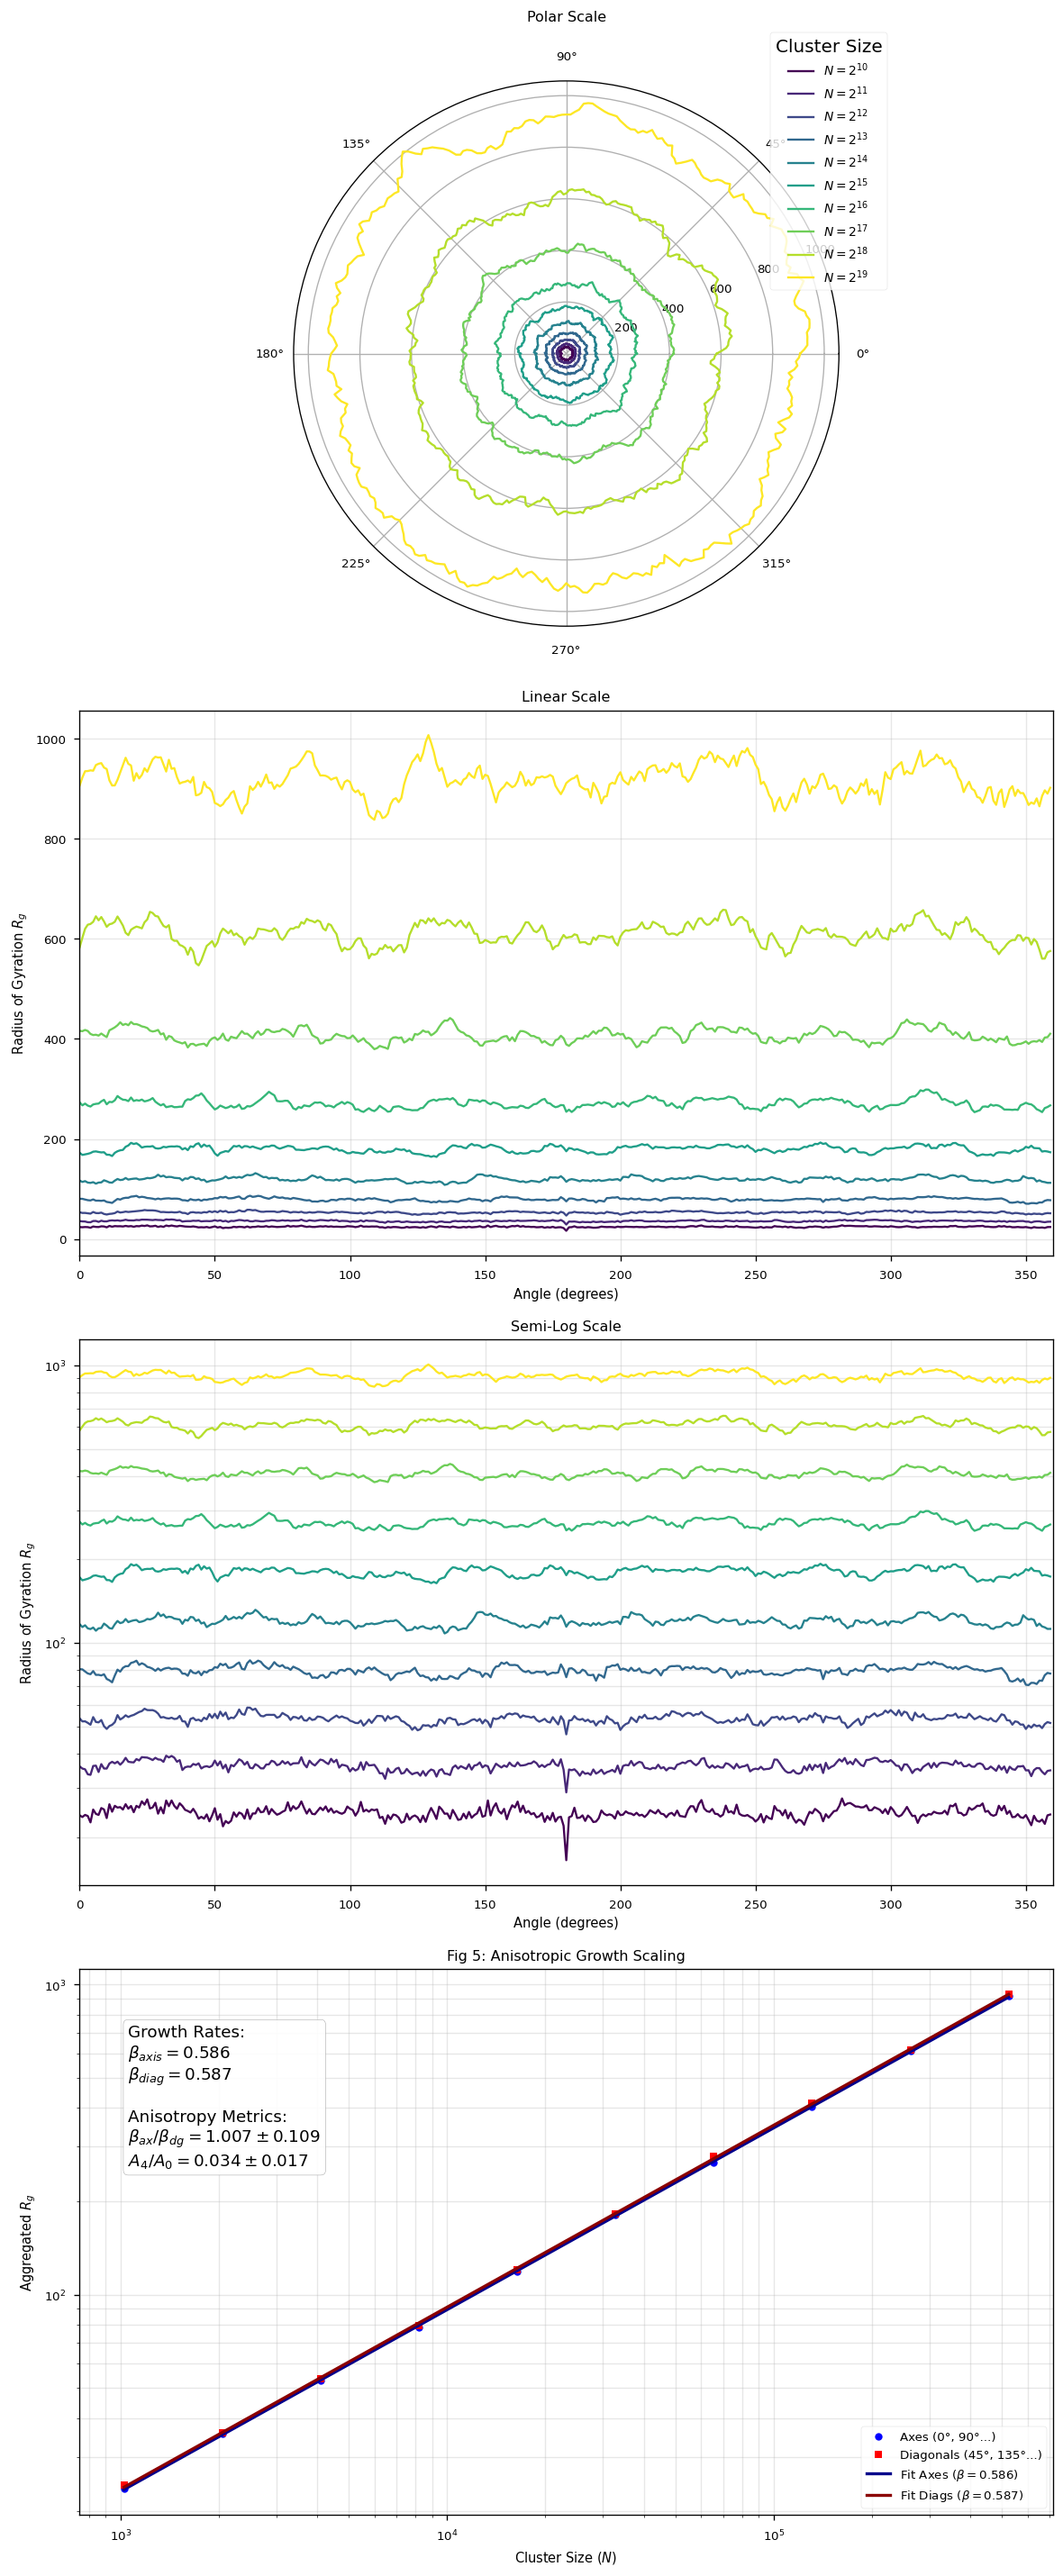

In [11]:
# --- STEP 4: VISUALISATION ---
if sector_data2 is not None:
    fig = plt.figure(figsize=(10, 28))
    ax_polar = fig.add_subplot(5, 1, 1, projection='polar')
    ax_linear = fig.add_subplot(5, 1, 2)
    ax_log = fig.add_subplot(5, 1, 3)
    ax_beta = fig.add_subplot(5, 1, 4)
    ax_scale = fig.add_subplot(5, 1, 5)
    viz.angular_rg_plot(times, sector_data2, ax_polar=ax_polar, ax_linear=ax_linear, ax_log=ax_log)
    viz.plot_beta_profile(times, sector_data2, ax=ax_beta)
    viz.comparing_axes_plot(times, sector_data2, summary_stats=summary2, ax=ax_scale)
    
    # Adjust spacing to prevent labels overlapping
    plt.tight_layout()
    plt.show()
else:
    print("No data to plot.")

>>> Generating Density Map...
Generating density grid for N=1000000 across 100 files...


100%|██████████| 100/100 [04:13<00:00,  2.53s/it]


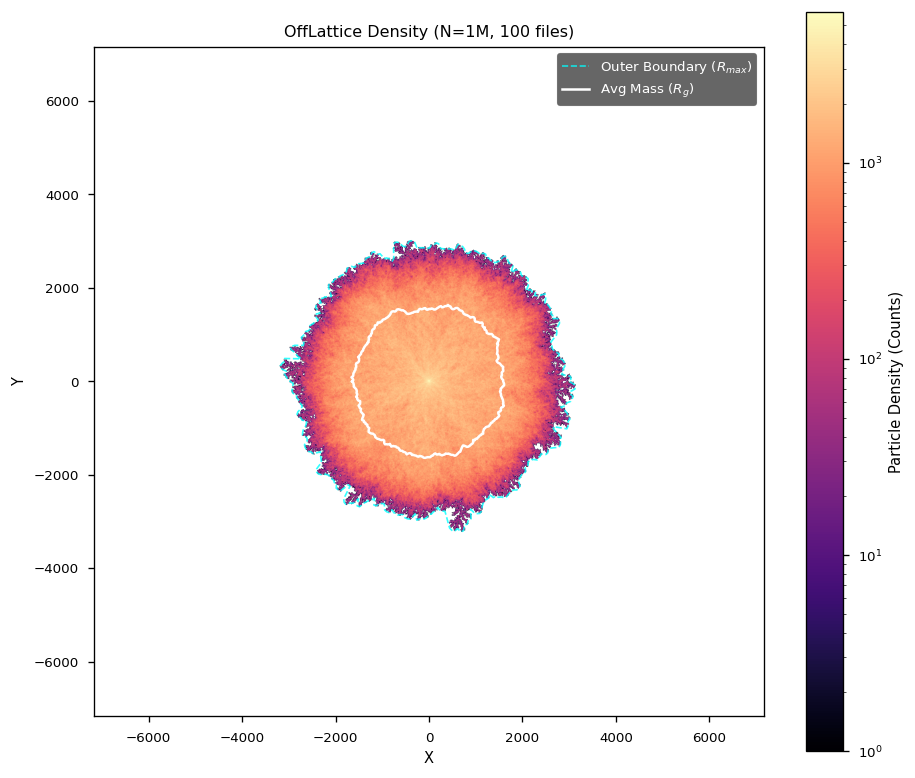

In [13]:
#  --- DENSITY MAP VERIFICATION ---
print(">>> Generating Density Map...")

grid, bins, max_r, rg_curve = proc.generate_density_grid(
    file_pattern=base_path2, 
    snapshot_N=1000000, 
    limit_files=TEST_LIMIT # Use same limit for consistency
)

fig = viz.plot_density_map(
    grid, bins, 
    max_r_curve=max_r, 
    rg_curve=rg_curve, 
    title=f"{MODEL_NAME2} Density (N=1M, {TEST_LIMIT} files)"
)
plt.show()

HYBRID

In [14]:
MODEL_NAME3 = 'Hybrid'


# Define Paths
base_path3 = os.path.join(project_root, f'results/analysis_clusters/{MODEL_NAME3}/{SIZE_LABEL}/*.npz')

print(f"Targeting Model: {MODEL_NAME3}")
print(f"Targeting Size:  {SIZE_LABEL}")
print(f"Test Limit:      {TEST_LIMIT} files")
print(f"Search Path:     {base_path3}")

Targeting Model: Hybrid
Targeting Size:  1M
Test Limit:      100 files
Search Path:     /Users/ramsaydavis/dla/results/analysis_clusters/Hybrid/1M/*.npz


In [15]:
print(">>> Running Basic Scalar Analysis...")

snapshots = [1000000] 

df_basic3 = proc.batch_analysis(
    file_pattern=base_path3, 
    snapshots=snapshots, 
    num_workers=NUM_CORES, 
    limit=TEST_LIMIT
)

# Display Summary
print("\n--- RESULTS SUMMARY ---")
print(f"Files Processed: {len(df_basic3)}")
if not df_basic3.empty:
    mean_beta = df_basic3['beta'].mean()
    std_beta  = df_basic3['beta'].std()
    mean_D    = df_basic3['D'].mean()
    std_D     = df_basic3['D'].std()
    
    print(f"Growth Rate (Beta): {mean_beta:.4f} ± {std_beta:.4f}")
    print(f"Fractal Dim (D):    {mean_D:.4f} ± {std_D:.4f}")
else:
    print("Error: DataFrame is empty.")

df_basic3.head()

>>> Running Basic Scalar Analysis...
Limiting to first 100 files for analysis.
Found 100 files to process. Starting analysis on 4 cores...


100%|██████████| 100/100 [01:45<00:00,  1.05s/it]



--- RESULTS SUMMARY ---
Files Processed: 100
Growth Rate (Beta): 0.5984 ± 0.0081
Fractal Dim (D):    1.6307 ± 0.0031


,filepath,snapshot_N,beta,beta_err,Rg_final,D,D_err
0,/Users/ramsaydavis/dla/results/analysis_cluste...,1000000,0.591874,0.000007,1623.340305,1.631200,0.009017
1,/Users/ramsaydavis/dla/results/analysis_cluste...,1000000,0.603989,0.000006,1638.603895,1.634440,0.009609
2,/Users/ramsaydavis/dla/results/analysis_cluste...,1000000,0.601487,0.000015,1702.471405,1.637177,0.009207
3,/Users/ramsaydavis/dla/results/analysis_cluste...,1000000,0.617175,0.000008,1732.335248,1.635199,0.009099
4,/Users/ramsaydavis/dla/results/analysis_cluste...,1000000,0.608182,0.000009,1674.587297,1.642102,0.010437


In [16]:
# --- STEP 2: SECTOR EVOLUTION ANALYSIS ---
print(">>> Running Sector Evolution Analysis...")

# extract full history (Rg vs Time) for 360 sectors
times, sector_data3 = proc.batch_sector_analysis(
    file_pattern=base_path3, 
    num_sectors=360, 
    num_workers=NUM_CORES, 
    limit=TEST_LIMIT
)

# Quality Check
if sector_data3 is not None:
    print("\n--- DATA SHAPE CHECK ---")
    print(f"Time Points (Checkpoints): {len(times)}")
    print(f"Time Values: {times}")
    print(f"Data Array (Files, Sectors, Times): {sector_data3.shape}")
    
    # Sanity check: Should not be all zeros
    print(f"Mean Rg at final time: {np.nanmean(sector_data3[:, :, -1]):.2f}")
else:
    print("Error: Sector analysis failed.")

>>> Running Sector Evolution Analysis...
Limiting to first 100 files for sector analysis.
Found 100 files to process for sector analysis on 4 cores...


100%|██████████| 100/100 [00:45<00:00,  2.18it/s]


Aggregated shape: (100, 360, 10) (files, sectors, time_steps)

--- DATA SHAPE CHECK ---
Time Points (Checkpoints): 10
Time Values: [  1024   2048   4096   8192  16384  32768  65536 131072 262144 524288]
Data Array (Files, Sectors, Times): (100, 360, 10)
Mean Rg at final time: 867.83


In [17]:
# --- STEP 3: COMPUTE ANISOTROPY STATISTICS ---
if sector_data3 is not None:
    print(">>> Computing Anisotropy Statistics...")
    
    # Calculate metrics for every single file in the batch
    # df_stats: DataFrame containing individual Beta_Ratio and Fourier_Score for each file
    # summary:  Dictionary containing the Mean +/- Std of the population
    df_stats3, summary3 = proc.compute_anisotropy_metrics(times, sector_data3)
    
    print("\n--- ANISOTROPY RESULTS ---")
    print(f"Beta Ratio (Beta_Ax / Beta_Diag): {summary3['beta_ratio_mean']:.4f} ± {summary3['beta_ratio_std']:.4f}")
    print(f"Anisotropy Score  (Fourier A4 / A0):     {summary3['fourier_score_mean']:.4f} ± {summary3['fourier_score_std']:.4f}")
    
    # Optional: Peek at the raw data to ensure no NaNs are skewing things
    print(f"\nValid Files Used: {len(df_stats3.dropna())} / {len(df_stats3)}")
    display(df_stats3.head())
else:
    print("Skipping metrics (No data).")

>>> Computing Anisotropy Statistics...
Computing anisotropy metrics for 100 files...


Anisotropy Metrics: 100%|██████████| 100/100 [00:29<00:00,  3.42it/s]


--- ANISOTROPY RESULTS ---
Beta Ratio (Beta_Ax / Beta_Diag): 1.1628 ± 0.1171
Anisotropy Score  (Fourier A4 / A0):     0.0538 ± 0.0198

Valid Files Used: 100 / 100


,beta_axis,beta_diag,beta_ratio,A0,A4,fourier_score
0,0.631976,0.586232,1.078032,0.567142,0.025560,0.045068
1,0.630248,0.521262,1.209082,0.567756,0.033905,0.059718
2,0.591520,0.576695,1.025708,0.560698,0.020545,0.036641
3,0.568163,0.524102,1.084069,0.568397,0.019279,0.033918
4,0.621131,0.495414,1.253762,0.572335,0.030327,0.052989


/Users/ramsaydavis/dla/src/analysis/plotting.py:76: RuntimeWarning: Mean of empty slice
  mean_profile = np.nanmean(agg_data, axis=0)  # shape: (num_sectors, time_points)
/Users/ramsaydavis/dla/src/analysis/plotting.py:144: RuntimeWarning: Mean of empty slice
  mean_grid = np.nanmean(agg_data, axis=0)


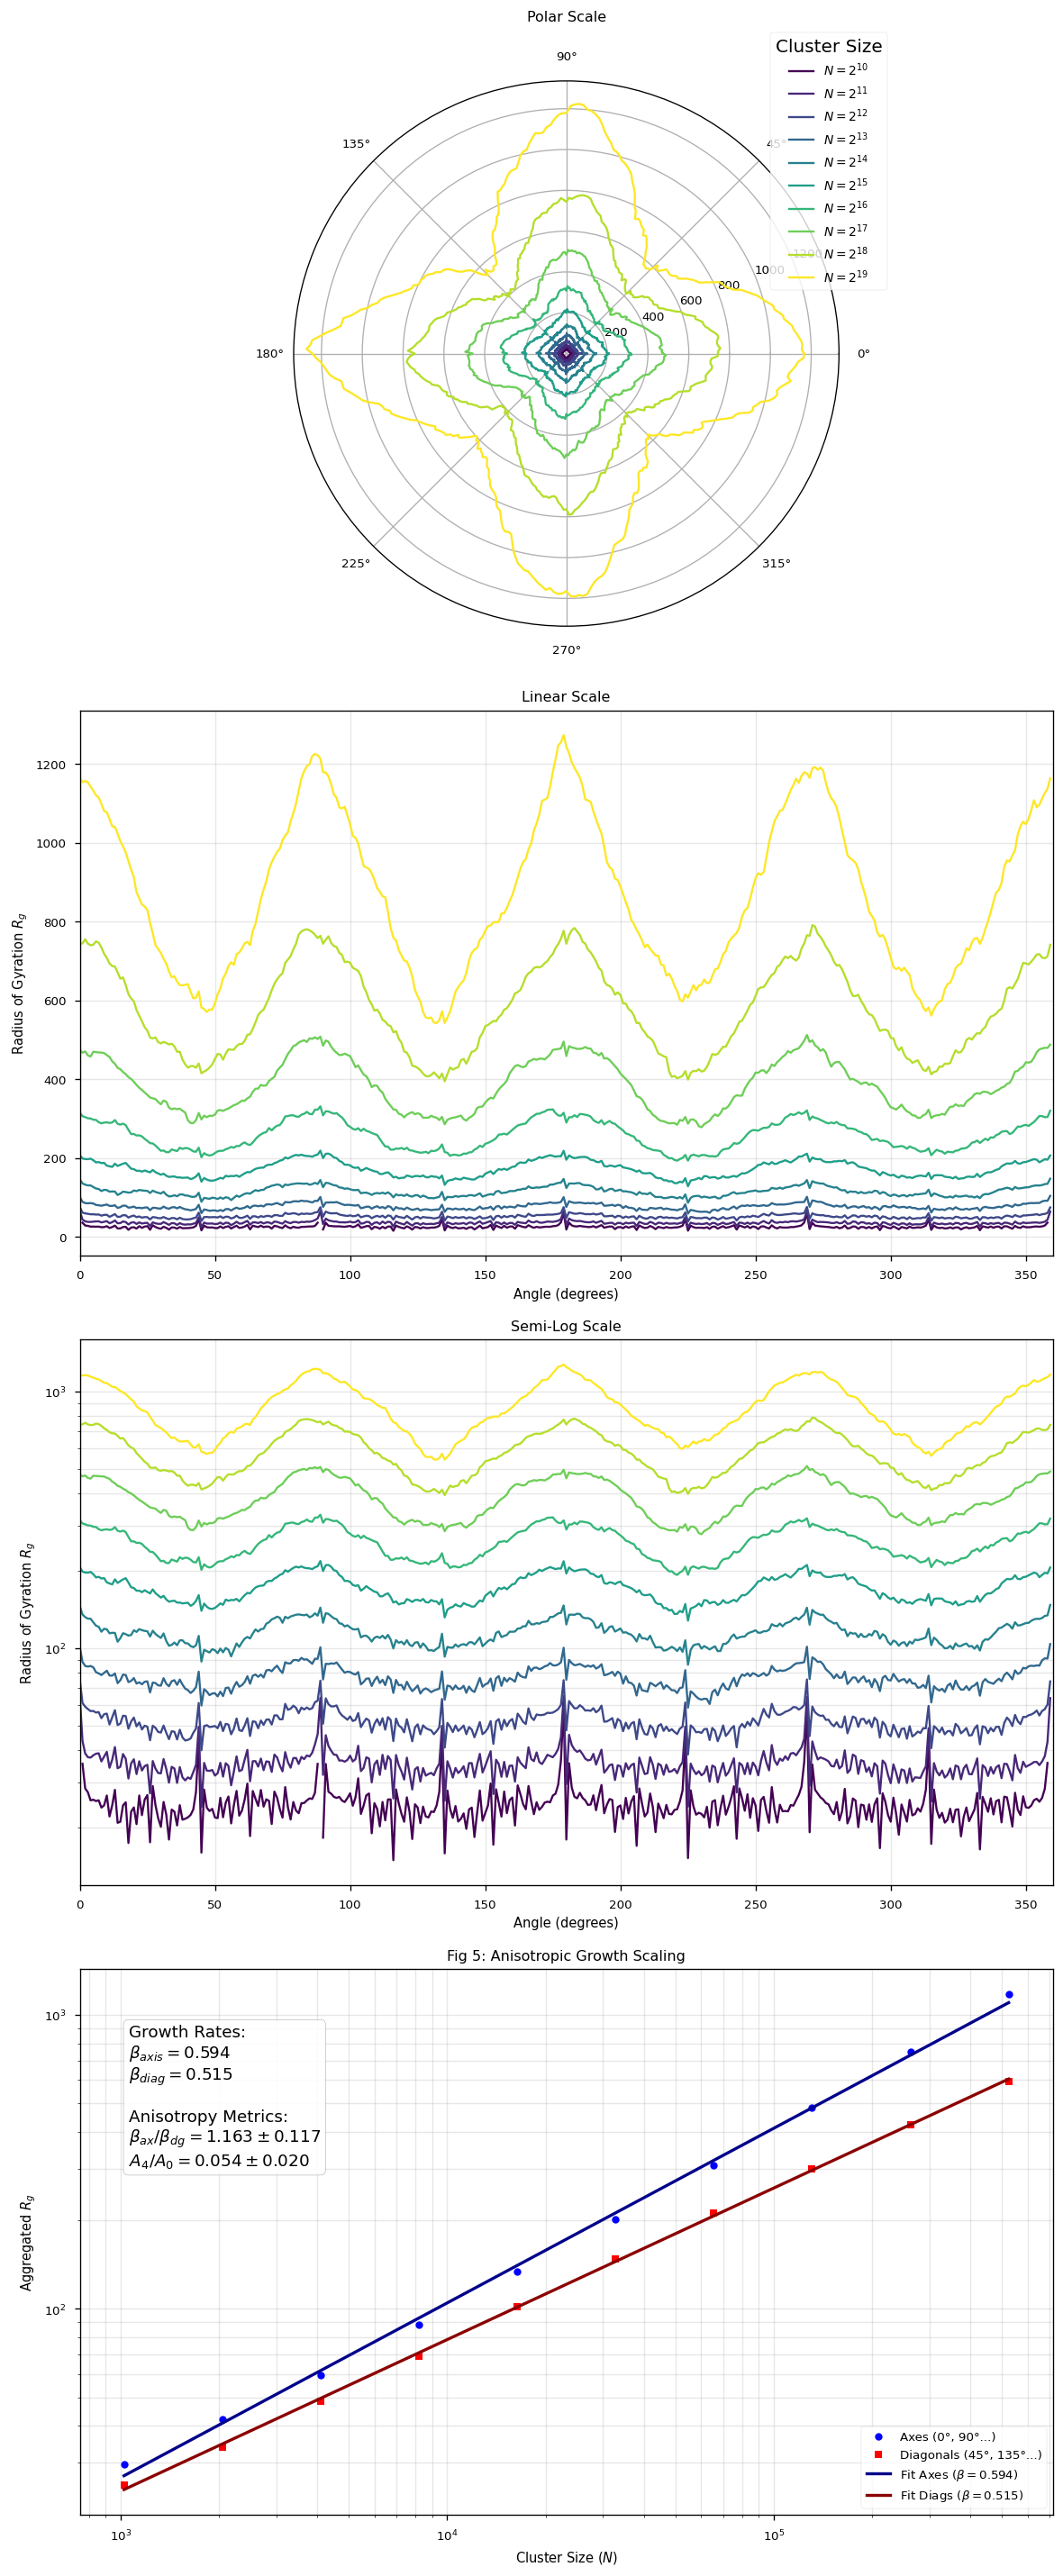

In [18]:
# --- STEP 4: VISUALISATION ---
if sector_data3 is not None:
    fig = plt.figure(figsize=(10, 28))
    ax_polar = fig.add_subplot(5, 1, 1, projection='polar')
    ax_linear = fig.add_subplot(5, 1, 2)
    ax_log = fig.add_subplot(5, 1, 3)
    ax_beta = fig.add_subplot(5, 1, 4)
    ax_scale = fig.add_subplot(5, 1, 5)
    viz.angular_rg_plot(times, sector_data3, ax_polar=ax_polar, ax_linear=ax_linear, ax_log=ax_log)
    viz.plot_beta_profile(times, sector_data3, ax=ax_beta)
    viz.comparing_axes_plot(times, sector_data3, summary_stats=summary3, ax=ax_scale)
    
    # Adjust spacing to prevent labels overlapping
    plt.tight_layout()
    plt.show()
else:
    print("No data to plot.")


>>> Generating Density Map...
Generating density grid for N=1000000 across 100 files...


100%|██████████| 100/100 [03:09<00:00,  1.89s/it]


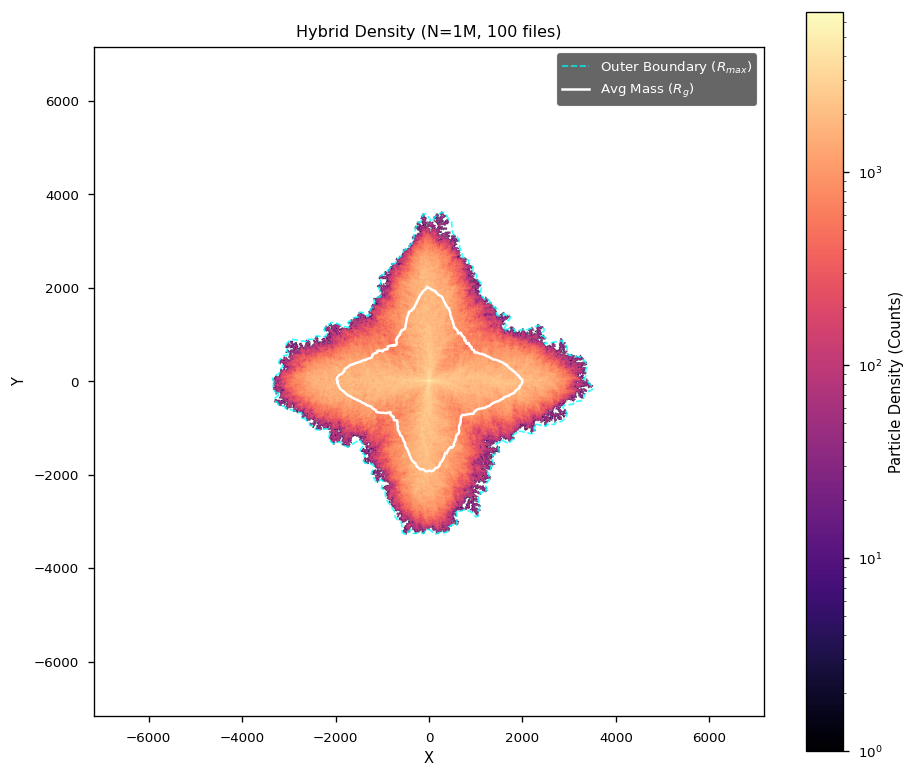

In [19]:
#  --- DENSITY MAP VERIFICATION ---
print(">>> Generating Density Map...")

grid, bins, max_r, rg_curve = proc.generate_density_grid(
    file_pattern=base_path3, 
    snapshot_N=1000000, 
    limit_files=TEST_LIMIT # Use same limit for consistency
)

fig = viz.plot_density_map(
    grid, bins, 
    max_r_curve=max_r, 
    rg_curve=rg_curve, 
    title=f"{MODEL_NAME3} Density (N=1M, {TEST_LIMIT} files)"
)
plt.show()